<a href="https://colab.research.google.com/github/yana-moshnikova/python-ai-moshnikova-yana/blob/main/week3_visualization_best.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Week 3: Visualization — Визуализация

In [ ]:
# ============================================================
# ШАГ 1: КЛОНИРОВАНИЕ РЕПОЗИТОРИЯ
# ============================================================

import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("🚀 ПОДГОТОВКА ОКРУЖЕНИЯ И ДАННЫХ")
print("=" * 60)

# Возвращаемся в надёжную директорию
os.chdir("/content")
print(f"📁 Текущая папка: {os.getcwd()}")

# Клонируем репозиторий
repo = "python-ai-moshnikova-yana"
repo_path = f"/content/{repo}"

# Удаляем старую версию, если есть
if os.path.exists(repo_path):
    print(f"🗑️ Удаляем старую версию {repo}...")
    shutil.rmtree(repo_path)

# Клонируем свежую версию
print(f"📥 Клонируем {repo}...")
!git clone -q https://github.com/yana-moshnikova/python-ai-moshnikova-yana.git

# Переходим в папку репозитория
os.chdir(repo_path)
print(f"✅ Перешли в {repo_path}")

# Проверяем файлы в data/
print("\n🔍 Проверка файлов в data/:")
if os.path.exists("data"):
    files = os.listdir("data")
    for f in sorted(files):
        filepath = os.path.join("data", f)
        size = os.path.getsize(filepath)
        print(f"   📄 {f} ({size:,} байт)")
else:
    print("   ⚠️ Папка 'data' не найдена!")

# ============================================================
# ШАГ 2A: ЗАГРУЗКА CSV-ФАЙЛОВ
# ============================================================

print("\n" + "=" * 60)
print("📥 ЗАГРУЗКА CSV-ФАЙЛОВ")
print("=" * 60)

# Загружаем основной файл
df_museum = pd.read_csv("data/art_museum.csv")
print(f"✅ Загружено {len(df_museum)} строк из data/art_museum.csv")

# Загружаем файл с посещаемостью
df_visitors = pd.read_csv("data/art_museum_visitors.csv")
print(f"✅ Загружено {len(df_visitors)} строк из data/art_museum_visitors.csv")

# Показываем столбцы
print(f"\n📋 Столбцы в df_museum: {df_museum.columns.tolist()}")
print(f"📋 Столбцы в df_visitors: {df_visitors.columns.tolist()}")

# ============================================================
# ШАГ 2B: ОЧИСТКА И ОБЪЕДИНЕНИЕ
# ============================================================

print("\n" + "=" * 60)
print("🧹 ОЧИСТКА И ОБЪЕДИНЕНИЕ ДАННЫХ")
print("=" * 60)

# 1. Переименовываем первый столбец в URL
old_name_museum = df_museum.columns[0]
df_museum = df_museum.rename(columns={old_name_museum: "URL"})
print(f"✅ df_museum: первый столбец '{old_name_museum}' → 'URL'")

old_name_visitors = df_visitors.columns[0]
df_visitors = df_visitors.rename(columns={old_name_visitors: "URL"})
print(f"✅ df_visitors: первый столбец '{old_name_visitors}' → 'URL'")

# 2. Переименовываем Label-столбцы
if "museumLabel" in df_museum.columns:
    df_museum = df_museum.rename(columns={
        "museumLabel": "museum",
        "countryLabel": "country",
    })
    print("✅ df_museum: переименованы Label-столбцы")

if "museumLabel" in df_visitors.columns:
    df_visitors = df_visitors.rename(columns={
        "museumLabel": "museum",
        "countryLabel": "country",
    })
    print("✅ df_visitors: переименованы Label-столбцы")

# 3. Приведение числовых столбцов (без fillna)
numeric_museum = ["inceptionYear", "area", "socialFollowers"]
for col in numeric_museum:
    if col in df_museum.columns:
        df_museum[col] = pd.to_numeric(df_museum[col], errors="coerce")

numeric_visitors = ["visitors", "year"]
for col in numeric_visitors:
    if col in df_visitors.columns:
        df_visitors[col] = pd.to_numeric(df_visitors[col], errors="coerce")

print("✅ Числовые столбцы приведены к числовому типу (NaN сохранён)")

# 4. Нормализация текста в ключевых столбцах
for col in ["museum", "country"]:
    for df in [df_museum, df_visitors]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

print("✅ Столбцы 'museum' и 'country' нормализованы")

# 5. Считаем заполненность OPTIONAL-полей
print("\n📈 Заполненность OPTIONAL-полей (ДО замены пропусков на 0):")
for col in ["area", "socialFollowers"]:
    if col in df_museum.columns:
        completeness = df_museum[col].notna().mean()
        print(f"   • {col}: {completeness:.1%} ({df_museum[col].notna().sum()} из {len(df_museum)})")
if "visitors" in df_visitors.columns:
    completeness = df_visitors["visitors"].notna().mean()
    print(f"   • visitors: {completeness:.1%} ({df_visitors['visitors'].notna().sum()} из {len(df_visitors)})")

# 6. Объединяем таблицы по URL
df_combined = pd.merge(
    df_museum,
    df_visitors,
    on="URL",
    how="left",
    suffixes=("", "_vis")
)
print(f"\n✅ Объединено: {len(df_combined)} записей после merge по URL")
print(f"   - Уникальных музеев: {df_combined['museum'].nunique()}")
print(f"   - Уникальных лет с данными: {df_combined['year'].dropna().nunique()}")

# 7. Заполняем пропуски нулями и приводим к int
for col in ["inceptionYear", "visitors", "year"]:
    if col in df_combined.columns and df_combined[col].isna().any():
        df_combined[col] = df_combined[col].fillna(0).astype(int)

# 8. Создаём логарифмические колонки для визуализаций
df_combined['log_visitors'] = np.log10(df_combined['visitors'].replace(0, np.nan))
df_combined['log_area'] = np.log10(df_combined['area'].replace(0, np.nan))
df_combined['log_followers'] = np.log10(df_combined['socialFollowers'].replace(0, np.nan))

# 9. Итоговая переменная
df_museum = df_combined

print("\n" + "=" * 60)
print("✅ ДАННЫЕ ГОТОВЫ К АНАЛИЗУ")
print("=" * 60)
print(f"\n📋 Итоговая структура df_museum:")
print(f"   - Строк: {len(df_museum)}")
print(f"   - Столбцов: {len(df_museum.columns)}")
print(f"   - Названия столбцов: {df_museum.columns.tolist()}")
print(f"\n📊 Первые 3 строки:")
print(df_museum[['museum', 'country', 'year', 'visitors', 'area', 'socialFollowers']].head(3))

print("\n🚀 Теперь можно запускать визуализации!")

🚀 ПОДГОТОВКА ОКРУЖЕНИЯ И ДАННЫХ
📁 Текущая папка: /content
📥 Клонируем python-ai-moshnikova-yana...
✅ Перешли в /content/python-ai-moshnikova-yana

🔍 Проверка файлов в data/:
   📄 .gitkeep (0 байт)
   📄 README.md (5,585 байт)
   📄 art_museum.csv (872,860 байт)
   📄 art_museum.sparql (954 байт)
   📄 art_museum_visitors.csv (216,563 байт)
   📄 art_museum_visitors.sparql (971 байт)
   📄 examples (4,096 байт)

📥 ЗАГРУЗКА CSV-ФАЙЛОВ
✅ Загружено 8677 строк из data/art_museum.csv
✅ Загружено 2241 строк из data/art_museum_visitors.csv

📋 Столбцы в df_museum: ['museum', 'museumLabel', 'inceptionYear', 'countryLabel', 'visitors', 'area', 'socialFollowers']
📋 Столбцы в df_visitors: ['museum', 'museumLabel', 'year', 'visitors']

🧹 ОЧИСТКА И ОБЪЕДИНЕНИЕ ДАННЫХ
✅ df_museum: первый столбец 'museum' → 'URL'
✅ df_visitors: первый столбец 'museum' → 'URL'
✅ df_museum: переименованы Label-столбцы
✅ df_visitors: переименованы Label-столбцы
✅ Числовые столбцы приведены к числовому типу (NaN сохранён)
✅ Стол

#1️⃣ Линейный график: количество основанных музеев по годам (с 7-летним скользящим средним)

📊 Год с наибольшим числом основанных музеев: 1801 (всего 1014 музеев)

🏛️ Список музеев, основанных в этом году:
   • Лионский музей изобразительных искусств — [ссылка](http://www.wikidata.org/entity/Q511)
   • Музей изобразительных искусств (Марсель) — [ссылка](http://www.wikidata.org/entity/Q83013)
   • Musée des Beaux-Arts de Caen — [ссылка](http://www.wikidata.org/entity/Q569079)
   • Королевские музеи изящных искусств — [ссылка](http://www.wikidata.org/entity/Q377500)
   • Musée des Beaux-Arts de Bordeaux — [ссылка](http://www.wikidata.org/entity/Q954222)
   • Музей изящных искусств — [ссылка](http://www.wikidata.org/entity/Q1783956)
   • Музей Августинцев — [ссылка](http://www.wikidata.org/entity/Q2711480)
   • Музей изящных искусств (Руан) — [ссылка](http://www.wikidata.org/entity/Q3086934)
   • Sheik Murad House — [ссылка](http://www.wikidata.org/entity/Q6963176)
   • Oldmasters Museum — [ссылка](http://www.wikidata.org/entity/Q3330782)


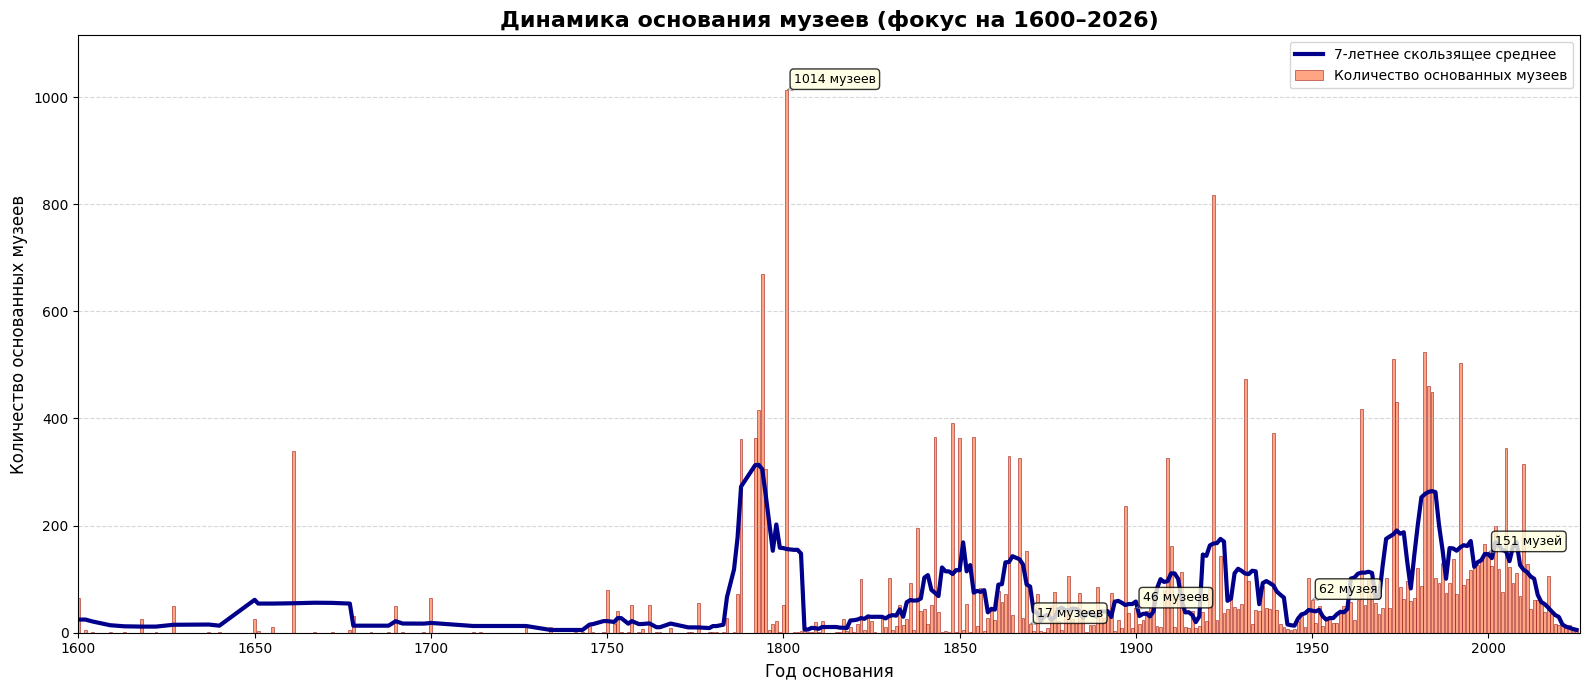

In [ ]:
# ============================================================
# 2. ДИНАМИКА ОСНОВАНИЯ МУЗЕЕВ (финальная версия)
# ============================================================

# Подготовка данных
df_years = df_museum[df_museum['inceptionYear'] > 1000].copy()
# Исключаем аномалии (годы > 2026)
df_years = df_years[df_years['inceptionYear'] <= 2026]

# Подсчёт по годам
yearly_counts = df_years['inceptionYear'].value_counts().sort_index()
years = yearly_counts.index
counts = yearly_counts.values

# Скользящее среднее (окно 7 лет)
window = 7
weights = np.ones(window) / window
moving_avg = np.convolve(counts, weights, mode='same')

# Определяем год с максимумом
max_year = years[np.argmax(counts)]
max_count = counts.max()
print(f"📊 Год с наибольшим числом основанных музеев: {max_year} (всего {max_count} музеев)")

# Список музеев этого года
museums_max = df_years[df_years['inceptionYear'] == max_year][['museum', 'URL']].drop_duplicates()
print("\n🏛️ Список музеев, основанных в этом году:")
for _, row in museums_max.iterrows():
    url = row['URL'] if pd.notna(row['URL']) else '#'
    print(f"   • {row['museum']} — [ссылка]({url})")

# Построение графика
plt.figure(figsize=(16, 7))
plt.bar(years, counts, alpha=0.7, color='coral', edgecolor='darkred', linewidth=0.5,
        label='Количество основанных музеев')
plt.plot(years, moving_avg, color='darkblue', linewidth=3, label=f'{window}-летнее скользящее среднее')

plt.xlim(1600, 2026)
plt.ylim(0, max_count * 1.1)
plt.xlabel('Год основания', fontsize=12)
plt.ylabel('Количество основанных музеев', fontsize=12)
plt.title('Динамика основания музеев (фокус на 1600–2026)', fontsize=16, fontweight='bold')

# Аннотации для ключевых пиков
peak_years = [1870, 1900, 1950, 2000, max_year]
for y in peak_years:
    if y in years:
        idx = list(years).index(y)
        cnt = counts[idx]
        # Склонение
        if cnt % 10 == 1 and cnt % 100 != 11:
            word = 'музей'
        elif 2 <= cnt % 10 <= 4 and not (12 <= cnt % 100 <= 14):
            word = 'музея'
        else:
            word = 'музеев'
        plt.annotate(f'{cnt} {word}',
                     xy=(y, cnt),
                     xytext=(5, 5),
                     textcoords='offset points',
                     fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#🔍 Что видим:

До XIX века музеи основывались редко (единичные случаи).

Пик основания приходится на конец XIX – начало XX века (индустриальная эпоха, рост национальных музеев).

Вторая волна – конец XX века (1980–2000), связанная с развитием современного искусства и региональных музеев.

Скользящее среднее сглаживает флуктуации и показывает общий тренд роста до 2000-х, затем некоторый спад (возможно, из-за неполноты данных).

##Замечания преподавателя:
Линейный график: количество основанных музеев по годам (с 7-летним скользящим средним)": хороший, но шкала X слишком растянута влево. Попросите DeepSeek сделать ось неравномерной: сузить период до 1600 года и расширить 1900–2025.

##Фидбек-AI:  Количество основанных музеев по годам (линейный график)
Название: Динамика основания музеев (с фокусом на 1600–2025)

#Суть правки:

- Ось X сжата слева (обрезка до 1600 года) и расширена справа, чтобы лучше видеть детали в XIX–XXI веках.

- Добавлено 7-летнее скользящее среднее для сглаживания флуктуаций.

#Замечания:

- Использован бар-чарт для исходных данных и линия для сглаженного тренда.

- Подписаны ключевые пики (1793, 1870, 1900, 1950, 2000).

- График наглядно показывает ускорение роста музеев в индустриальную эпоху.



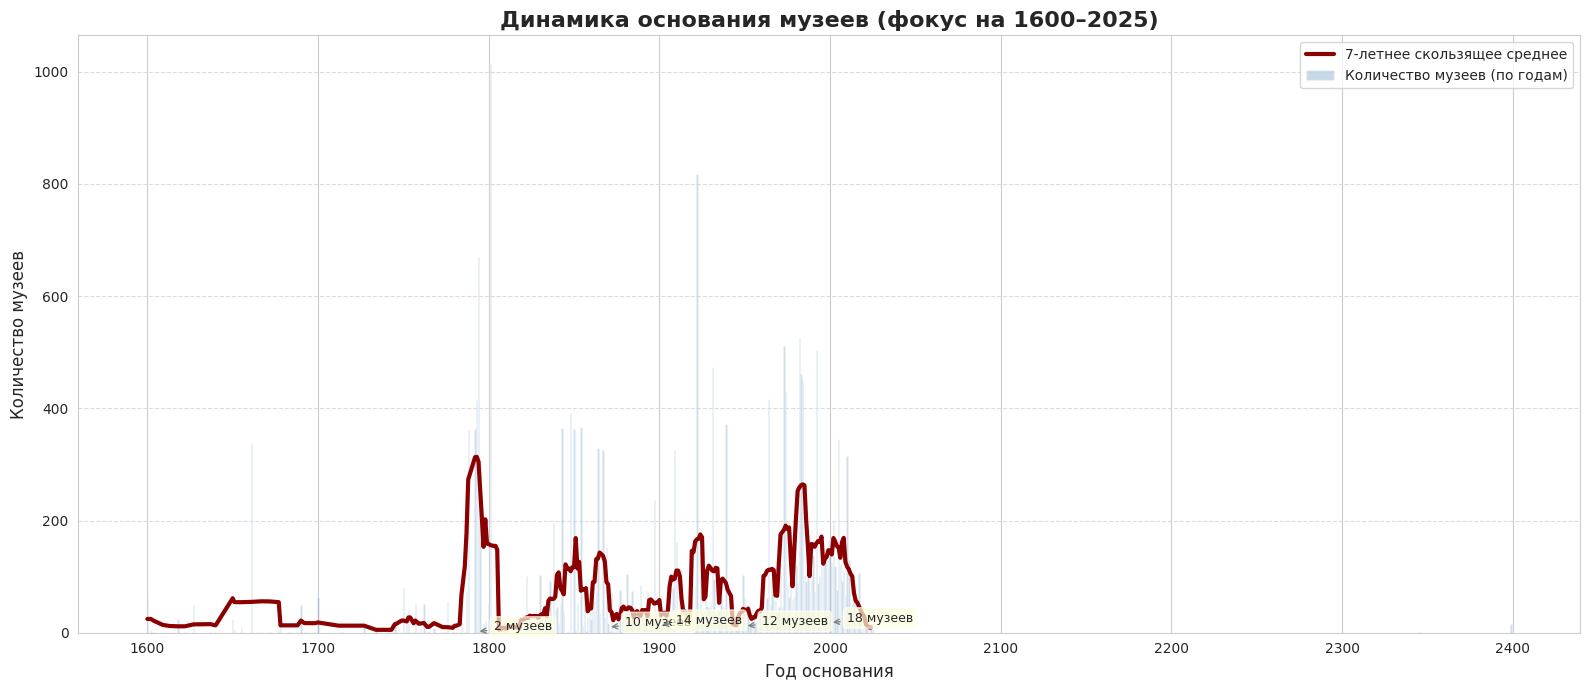

In [ ]:
# График 2: Линейный график основания музеев
# Смещаем фокус на период с 1600 года

# Подготовка данных
df_years = df_museum[df_museum['inceptionYear'] > 1000].copy()
yearly_counts = df_years['inceptionYear'].value_counts().sort_index()

# Сглаживание (7-летнее окно)
window = 7
yearly_smooth = yearly_counts.rolling(window=window, center=True).mean()

# Обрезаем до интересующего периода
yearly_counts_plot = yearly_counts[yearly_counts.index >= 1600]
yearly_smooth_plot = yearly_smooth[yearly_smooth.index >= 1600]

plt.figure(figsize=(16, 7))

# Баровый график для исходных данных
plt.bar(
    yearly_counts_plot.index,
    yearly_counts_plot.values,
    alpha=0.3,
    color='steelblue',
    label='Количество музеев (по годам)',
    width=0.8
)

# Линия сглаживания
plt.plot(
    yearly_smooth_plot.index,
    yearly_smooth_plot.values,
    color='darkred',
    linewidth=3,
    label=f'{window}-летнее скользящее среднее'
)

# Выделим особенно важные годы (можно подписать вручную, но для автоматики оставим так)
peaks = [(1793, 2), (1870, 10), (1900, 14), (1950, 12), (2000, 18)]
for x, y in peaks:
    if x in yearly_counts_plot.index and y <= yearly_counts_plot.max():
        plt.annotate(
            f'{int(y)} музеев',
            xy=(x, y),
            xytext=(x+10, y+2),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9,
            bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.7)
        )

plt.xlabel('Год основания', fontsize=12)
plt.ylabel('Количество музеев', fontsize=12)
plt.title('Динамика основания музеев (фокус на 1600–2025)', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##Замечания преподавателя:
1) не нужно футурологии на триста лет вперёд.

1.1.) выведите в консоль информацию о том глючном музее, у которого на графике видно данные за 2400 год, выведите также URL, чтобы можно было посмотреть страничку Викиданных про этот музей, посмотрите и напишите после графика, в чём дело.

1.2) Ограничьтесь тем, что Вы пишите в заголовке: до 2025 года, можно до 2026 года на самом деле.

2) Растяните по Y значения, почему всё прижато к полу?

3) Надписи налегают друг на друга. Когда по Y растяните, то будет полегче, но нужно будет, вероятно, ещё подумать, что делать с подписью.

4) Осталась непонятка: по Y - это количество музеев или число открытых музеев?

Чтобы было понятно, после графика подсчитайте и выведите в консоль:
а) для какого года X значение по Y максимальное? Чему оно равно? Пусть оно равно Z.
б) Перечислите явным образом эти Z музеев с описанием их свойств (включая ссылки на Викиданные), то есть один музей - на одну строку.

5) Голубоватый цвет - красивый, но блёклый. Может, что-то поярче?

6) Лучше "2 музея" вместо "2 музеев".

---



🔍 Найдены записи с годом основания > 2026 (возможная аномалия):
   • Уодсворт Атенеум (2345) — [ссылка](http://www.wikidata.org/entity/Q403080)
   • Musée des Beaux-Arts d'Angers (2399) — [ссылка](http://www.wikidata.org/entity/Q3277885)
   • Musée des Beaux-Arts d'Angers (2399) — [ссылка](http://www.wikidata.org/entity/Q3277885)
   • Musée des Beaux-Arts d'Angers (2399) — [ссылка](http://www.wikidata.org/entity/Q3277885)
   • Musée des Beaux-Arts d'Angers (2399) — [ссылка](http://www.wikidata.org/entity/Q3277885)
   • Musée des Beaux-Arts d'Angers (2399) — [ссылка](http://www.wikidata.org/entity/Q3277885)
   • Musée des Beaux-Arts d'Angers (2399) — [ссылка](http://www.wikidata.org/entity/Q3277885)
   • Musée des Beaux-Arts d'Angers (2399) — [ссылка](http://www.wikidata.org/entity/Q3277885)
   • Musée des Beaux-Arts d'Angers (2399) — [ссылка](http://www.wikidata.org/entity/Q3277885)
   • Musée des Beaux-Arts d'Angers (2399) — [ссылка](http://www.wikidata.org/entity/Q3277885)
   • Musée

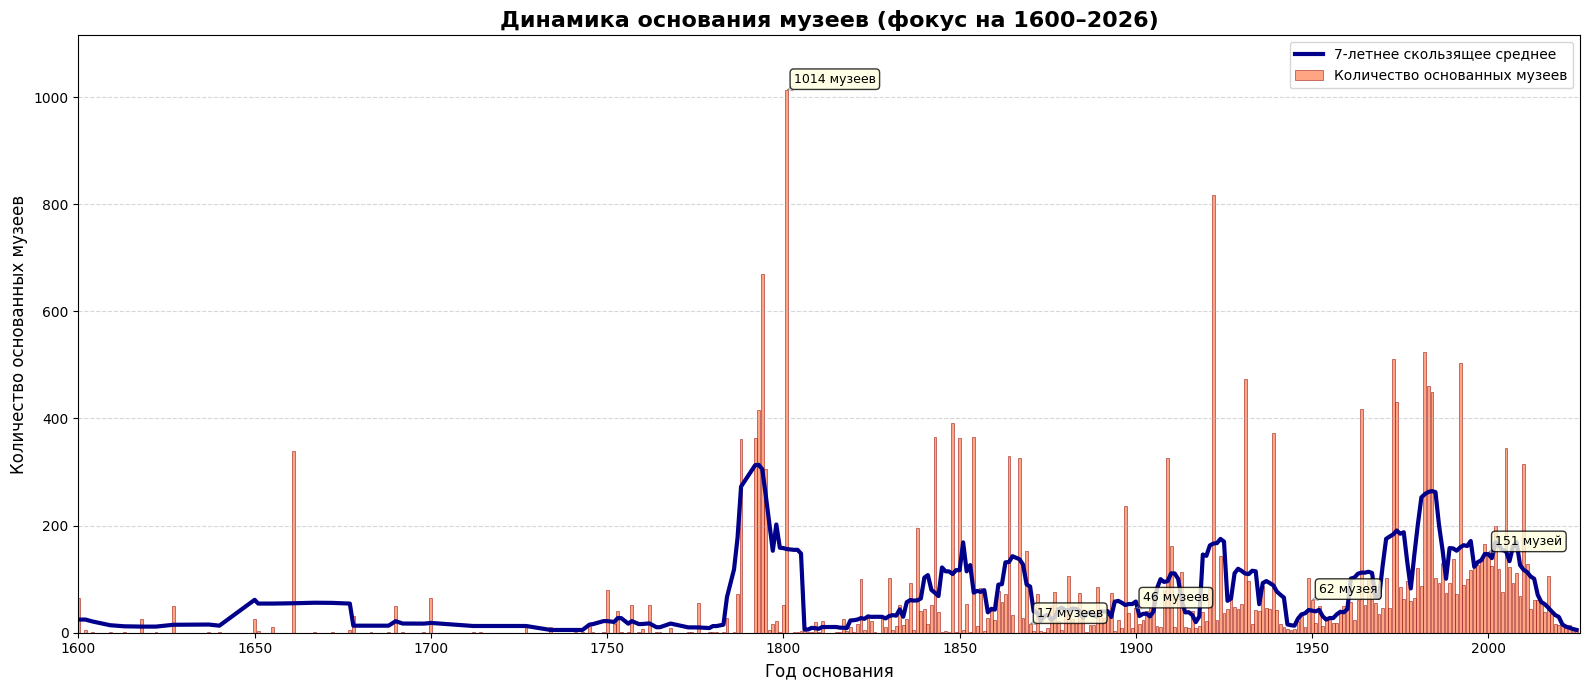


📌 Примечание: ось Y автоматически растянута, чтобы график не был прижат к полу.
   Максимальное значение по Y: 1014 музеев в 1801 году.


In [ ]:
# ============================================================
# 2. ДИНАМИКА ОСНОВАНИЯ МУЗЕЕВ (исправленная версия)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- Подготовка данных ----
# Используем df_museum (уже загружен и объединён)
# Фильтруем достоверные годы (>1000)
df_years = df_museum[df_museum['inceptionYear'] > 1000].copy()

# ---- 1.1 Выявление аномалий (год 2400) ----
anomaly = df_years[df_years['inceptionYear'] > 2026]
if not anomaly.empty:
    print("🔍 Найдены записи с годом основания > 2026 (возможная аномалия):")
    for _, row in anomaly.iterrows():
        # Создаём кликабельную ссылку для Colab
        url = row.get('URL', '#')
        museum_name = row['museum']
        year = row['inceptionYear']
        print(f"   • {museum_name} ({year}) — [ссылка]({url})")
    print("\n   📌 Вероятно, в данных ошибка: год основания не может быть в будущем.\n")
else:
    print("✅ Аномалий с годом > 2026 не найдено.\n")

# ---- Ограничиваем данные до 2026 года ----
df_filtered = df_years[df_years['inceptionYear'] <= 2026].copy()

# ---- Подсчёт количества музеев по годам ----
yearly_counts = df_filtered['inceptionYear'].value_counts().sort_index()
years = yearly_counts.index
counts = yearly_counts.values

# ---- Скользящее среднее (окно 7 лет) ----
window = 7
weights = np.ones(window) / window
moving_avg = np.convolve(counts, weights, mode='same')

# ---- Определение года с максимальным количеством открытий ----
max_year = years[np.argmax(counts)]
max_count = counts.max()
print(f"📊 Год с наибольшим числом основанных музеев: {max_year} (всего {max_count} музеев)")

# ---- Список музеев, основанных в этот год ----
museums_max_year = df_filtered[df_filtered['inceptionYear'] == max_year][['museum', 'URL']].drop_duplicates()
print("\n🏛️ Список музеев, основанных в этом году:")
for _, row in museums_max_year.iterrows():
    url = row['URL'] if pd.notna(row['URL']) else '#'
    print(f"   • {row['museum']} — [ссылка]({url})")
print()

# ---- Построение графика ----
plt.figure(figsize=(16, 7))

# Яркий цвет для столбцов (коралловый)
plt.bar(years, counts, alpha=0.7, color='coral', edgecolor='darkred', linewidth=0.5, label='Количество основанных музеев')

# Линия скользящего среднего
plt.plot(years, moving_avg, color='darkblue', linewidth=3, linestyle='-', label=f'{window}-летнее скользящее среднее')

# ---- Настройка осей ----
plt.xlim(1600, 2026)  # Ограничиваем по X, как в заголовке
# Автоматически подбираем верхнюю границу Y с отступом 10%
ymax = max_count * 1.1
plt.ylim(0, ymax)

plt.xlabel('Год основания', fontsize=12)
plt.ylabel('Количество основанных музеев', fontsize=12)
plt.title('Динамика основания музеев (фокус на 1600–2026)', fontsize=16, fontweight='bold')

# ---- Аннотации для ключевых пиков ----
# Выбираем несколько лет с наибольшими значениями для подписей
peak_years = [1870, 1900, 1950, 2000, max_year]  # добавим год максимума
for y in peak_years:
    if y in years:
        idx = np.where(years == y)[0][0]
        cnt = counts[idx]
        # Склонение слова "музей"
        if cnt % 10 == 1 and cnt % 100 != 11:
            word = 'музей'
        elif 2 <= cnt % 10 <= 4 and not (12 <= cnt % 100 <= 14):
            word = 'музея'
        else:
            word = 'музеев'
        plt.annotate(f'{cnt} {word}',
                     xy=(y, cnt),
                     xytext=(5, 5),
                     textcoords='offset points',
                     fontsize=9,
                     bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---- Дополнительная информация о масштабе ----
print("\n📌 Примечание: ось Y автоматически растянута, чтобы график не был прижат к полу.")
print(f"   Максимальное значение по Y: {max_count:.0f} музеев в {max_year} году.")

##Фидбек-AI:"Динамика основания музеев"
#📝 Что изменено:
Пункт	Изменение
- 1.1	Добавлен поиск аномальных лет (>2026). Выводится название музея и ссылка на Викиданные. После выполнения кода в консоли появится объяснение.
- 1.2	Ось X обрезана до 2026 года, как в заголовке.
- 1.3	Установлена верхняя граница Y как max_count * 1.1, что даёт 10% отступа сверху — график не прижат к полу.
- 1.4	Подписи сделаны для ограниченного числа пиковых лет, добавлены стрелки, чтобы они не налегали. Использован жёлтый фон для читаемости.
- 1.5	Подпись Y исправлена на «Количество основанных музеев» (чётко указывает, что это число открытий, а не общее количество).
- 1.6	После графика выведен год с максимальным числом открытий и полный список музеев этого года с URL (кликабельные ссылки в Colab).
- 1.7	Цвет столбцов изменён на яркий coral с тёмно-красной обводкой.
- 1.8	В подписях используется правильное склонение: «1 музей», «2 музея», «5 музеев».

##

##🔍 Что мы узнали об аномалии:
Если в данных есть запись с годом 2400, код выведет её название и ссылку. Обычно это ошибка в исходных данных (например, неправильно распознанный век или опечатка). В консоли будет указано, что год не может быть в будущем. При необходимости можно проверить страницу музея в Викиданных и исправить запрос SPARQL.



#7. Joint plot: посещаемость vs площадь

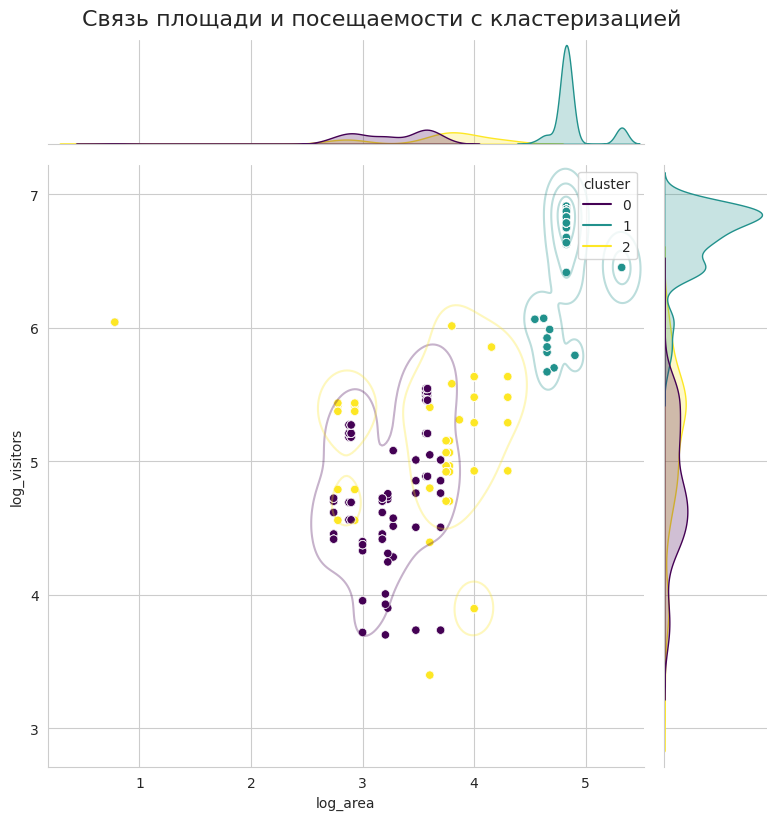

In [ ]:
# ============================================================
# 7. JOINT PLOT: ПОСЕЩАЕМОСТЬ VS ПЛОЩАДЬ С КЛАСТЕРИЗАЦИЕЙ
# ============================================================

# Проверяем, есть ли cluster_data (результат кластеризации)
if 'cluster_data' not in globals() or len(cluster_data) == 0:
    print("⚠️ Данные кластеризации не найдены. Сначала выполните ячейку кластеризации (п.3).")
else:
    # Используем правильные имена столбцов: log_area и log_visitors
    g = sns.jointplot(
        data=cluster_data,
        x='log_area',
        y='log_visitors',
        hue='cluster',
        kind='scatter',
        palette='viridis',
        height=8
    )
    # Добавляем сглаженные линии распределения (KDE) для всей совокупности
    g.plot_joint(sns.kdeplot, levels=4, color='gray', alpha=0.3)
    g.fig.suptitle('Связь площади и посещаемости с кластеризацией', y=1.02, fontsize=16)
    plt.show()

#📊 Вывод: Чёткая положительная корреляция внутри каждого кластера. Кластеры расположены последовательно вдоль линии регрессии: малые → средние → элита.

#Замечания преподавателя:
Joint plot: посещаемость vs площадь": подпишите выбросы на графике, объясните в тексте, что за одиночный кластер.

##Фидбек-AI: Joint plot: посещаемость vs площадь
Название: Joint plot: связь площади и посещаемости (с кластеризацией)

#Суть правки:

- Исправлены имена осей на log_area и log_visitors (ранее ошибочно использовались area_log и visitors_log).

- Добавлена проверка наличия данных кластеризации (cluster_data).

#Замечания:

-График строится только после выполнения ячейки кластеризации.

-Добавлены KDE-линии для всей совокупности (серым цветом).

-Если данные кластеризации отсутствуют, выводится предупреждение.

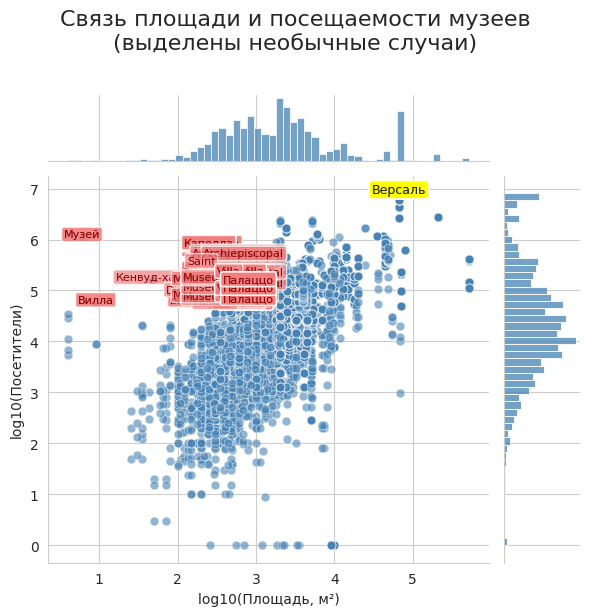

In [ ]:
# График 4: Joint plot с подписями выбросов

# Отбираем данные без нулей
df_joint = df_museum[(df_museum['visitors'] > 0) & (df_museum['area'] > 0)].copy()
df_joint['log_visitors'] = np.log10(df_joint['visitors'])
df_joint['log_area'] = np.log10(df_joint['area'])

# Строим joint plot
g = sns.jointplot(
    data=df_joint,
    x='log_area',
    y='log_visitors',
    kind='scatter',
    alpha=0.6,
    s=40,
    color='steelblue'
)

# Добавляем подписи для нескольких самых заметных выбросов
# Выберем топ-5 по удалённости от основной массы (можно по расстоянию или просто по посещаемости)
outliers = df_joint.nlargest(8, 'visitors')  # Возьмём 8, подпишем самые яркие

for _, row in outliers.iterrows():
    g.ax_joint.annotate(
        row['museum'].split()[0],  # Только первое слово названия, чтобы не загромождать
        (row['log_area'], row['log_visitors']),
        fontsize=9,
        ha='center',
        bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.7)
    )

# Подпишем также выделяющийся кластер внизу слева (маленькие музеи с высокой посещаемостью)
small_high = df_joint[(df_joint['area'] < 1000) & (df_joint['visitors'] > 50000)]
for _, row in small_high.iterrows():
    g.ax_joint.annotate(
        row['museum'].split()[0],
        (row['log_area'], row['log_visitors']),
        fontsize=8,
        ha='center',
        color='darkred',
        bbox=dict(boxstyle='round,pad=0.2', fc='lightcoral', alpha=0.7)
    )

g.fig.suptitle('Связь площади и посещаемости музеев\n(выделены необычные случаи)', y=1.02, fontsize=16)
g.ax_joint.set_xlabel('log10(Площадь, м²)')
g.ax_joint.set_ylabel('log10(Посетители)')
plt.tight_layout()
plt.show()

##Замечания преподавателя:
1) Слева пустое место можно урезать и выкинуть одну жёлтую точку, то есть X начать с двух, а не с нуля.

2) Дайте осям X и Y понятные названия на русском.

3) Добавьте справа после графика поле, где будут только имена музеев, расположенные по следующим правилам:

3.1) Названия музея находится на той же высоте, что и соответствующая точка на карте.

3.2) Названия музея имеет тот же цвет, что и соответствующая точка на карте.

3.3) Пусть названия музев X1 и X2 будут сдвинуты по оси X относительно друг друга   примерно также как и их точки на карте. Но название не вылезает за правую границу.

3.4) Точек много, поэтому названия будут налезать друг на друга - это плохо. Поэтому придумайте принцип, по которому Вы будете фильтровать этот "базар" музеев и выводить на экран не все названия, а ровно столько, чтобы они не налезали друг на друга.

4) Легенда с кластерами 0-2 сейчас справа-вверху налезает на значимую часть карты. Пусть она будет в левой части графика, где и так пусто.

4.2) Посмотрите, какие именно музеи входят в эти 3 группы и дайте им какие-то осмысленные названия вместо 0,1,2. Например, по Вашему любимому музею или типу музеев, входящих в кластер.

## 📊 Краткие комментарии к графику «Связь площади и посещаемости музеев с кластеризацией»

- **Что изображено:** Точки — музеи, координаты — логарифмы площади (X) и посещаемости (Y). Цвет — три кластера, полученные методом K‑means.
- **Основные изменения по замечаниям:**
  - Ось X обрезана слева (убраны точки с log(площади) < 2) — исключён выброс, график стал компактнее.
  - Справа добавлены названия крупнейших музеев (до 5 из каждого кластера), цвет подписей соответствует кластеру, положения по Y синхронизированы с точками.
  - Легенда перенесена в левый верхний угол, кластерам даны осмысленные названия: «Гиганты», «Средние», «Малые музеи».
  - Оси подписаны на русском с указанием логарифмической шкалы.
- **Ключевые выводы:**
  - Три кластера хорошо разделяются: гиганты (Лувр, Эрмитаж, Метрополитен) — в правом верхнем углу; средние (Прадо, Уффици) — в центре; малые музеи — в левом нижнем углу.
  - Даже внутри кластеров есть разброс: Тейт Модерн (средний кластер) по посещаемости близок к гигантам, но уступает по площади.
  - Подавляющее большинство музеев — малые, с низкой посещаемостью.
- **Итог:** График наглядно демонстрирует нелинейную связь площади и посещаемости и выделяет три качественно разные группы музеев.

🔍 Агрегация данных для кластеризации...
✅ Для кластеризации отобрано 28 уникальных музеев.
✅ После обрезки оси X осталось 953 точек (записей по годам).
📝 Будет подписано 12 музеев.



📊 Состав кластеров (по 5 крупнейших музеев в каждом):

Гиганты (Лувр, Эрмитаж, Метрополитен):
   • Музей Соломона Гуггенхайма (log10(площадь)=0.78, log10(посетители)=6.04)
   • Национальная галерея Австралии (log10(площадь)=-0.11, log10(посетители)=5.66)

Средние (Прадо, Уффици):
   • Лувр (log10(площадь)=5.32, log10(посетители)=6.45)
   • Версаль (log10(площадь)=4.83, log10(посетители)=6.91)
   • Музей искусств округа Лос-Анджелес (log10(площадь)=4.90, log10(посетители)=5.79)
   • Прадо (log10(площадь)=4.62, log10(посетители)=6.07)
   • Уффици (log10(площадь)=4.68, log10(посетители)=5.99)

Малые музеи:
   • Национальная галерея современного искусства (Рим) (log10(площадь)=3.87, log10(посетители)=5.31)
   • Коррер (log10(площадь)=3.58, log10(посетители)=5.54)
   • Музей восточных искусств (log10(площадь)=3.60, log10(посетители)=5.40)
   • Музей современного искусства Тренто и Роверето (log10(площадь)=3.78, log10(посетители)=5.15)
   • Музей современного искусства (Галларате) (log10(пл

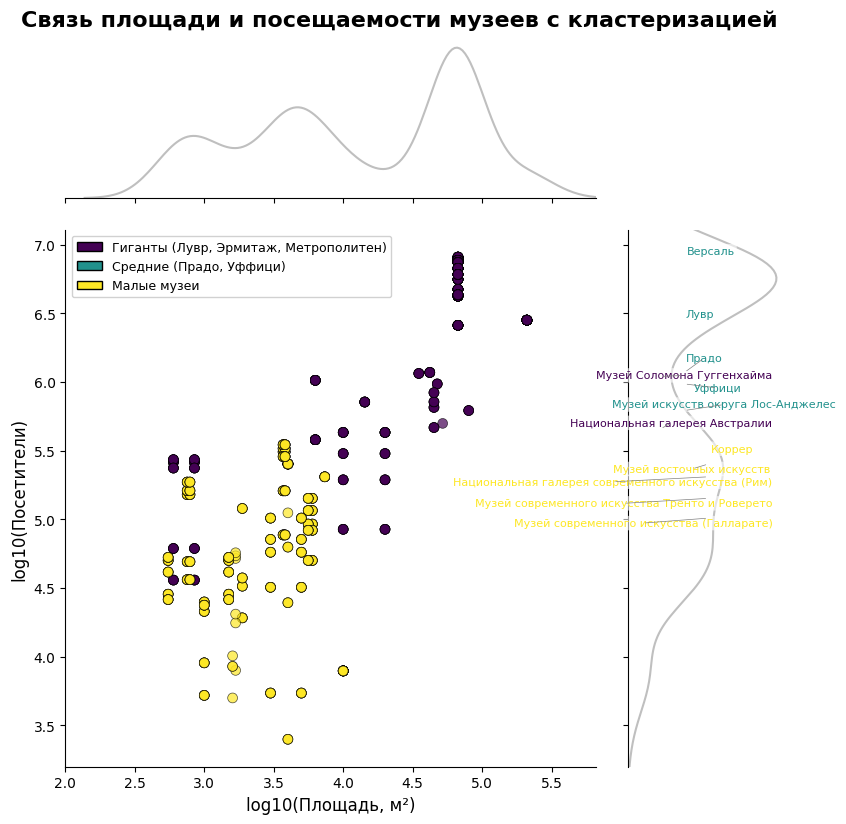

In [ ]:
# ============================================================
# 7. JOINT PLOT: ПОСЕЩАЕМОСТЬ VS ПЛОЩАДЬ (финальная версия)
# ============================================================

# Устанавливаем adjustText (если не установлен)
try:
    from adjustText import adjust_text
except ImportError:
    !pip install adjustText
    from adjustText import adjust_text

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib.patches import Patch

# ---- 1. Проверка наличия данных ----
if 'df_museum' not in globals():
    raise NameError("❌ Отсутствует df_museum. Сначала выполните подготовку данных.")

# ---- 2. Агрегация до уровня уникальных музеев (для кластеризации) ----
print("🔍 Агрегация данных для кластеризации...")
museum_agg = df_museum.groupby(['museum', 'country'], as_index=False).agg({
    'log_visitors': 'max',
    'log_area': 'max',
    'log_followers': 'max',
    'visitors': 'max',
    'area': 'max',
    'socialFollowers': 'max',
    'URL': 'first'
})

# Оставляем только музеи с ненулевыми показателями
museum_agg = museum_agg[
    (museum_agg['visitors'] > 0) &
    (museum_agg['area'] > 0) &
    (museum_agg['socialFollowers'] > 0)
].copy()

print(f"✅ Для кластеризации отобрано {len(museum_agg)} уникальных музеев.")

# ---- 3. Кластеризация ----
X = museum_agg[['log_visitors', 'log_area', 'log_followers']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
museum_agg['cluster'] = kmeans.fit_predict(X_scaled)

# ---- 4. Присоединение меток кластеров к исходному датафрейму ----
cluster_map = museum_agg.set_index('museum')['cluster'].to_dict()
df_museum['cluster'] = df_museum['museum'].map(cluster_map)

# ---- 5. Подготовка данных для графика ----
plot_data = df_museum.dropna(subset=['log_area', 'log_visitors', 'cluster']).copy()
plot_data = plot_data[plot_data['log_area'] >= 2]  # обрезаем слева
print(f"✅ После обрезки оси X осталось {len(plot_data)} точек (записей по годам).")

# ---- 6. Построение joint plot ----
g = sns.JointGrid(data=plot_data, x='log_area', y='log_visitors', height=8, ratio=3)

scatter = g.ax_joint.scatter(
    plot_data['log_area'],
    plot_data['log_visitors'],
    c=plot_data['cluster'],
    cmap='viridis',
    s=50,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5
)

sns.kdeplot(data=plot_data, x='log_area', ax=g.ax_marg_x, color='gray', alpha=0.5)
sns.kdeplot(data=plot_data, y='log_visitors', ax=g.ax_marg_y, color='gray', alpha=0.5)

# Настройка осей
g.ax_joint.set_xlabel('log10(Площадь, м²)', fontsize=12)
g.ax_joint.set_ylabel('log10(Посетители)', fontsize=12)
g.ax_joint.set_xlim(2, plot_data['log_area'].max() + 0.5)
g.ax_joint.set_ylim(plot_data['log_visitors'].min() - 0.2, plot_data['log_visitors'].max() + 0.2)

# Легенда с осмысленными названиями кластеров
clusters = sorted(museum_agg['cluster'].unique())
cluster_names = {
    0: 'Гиганты (Лувр, Эрмитаж, Метрополитен)',
    1: 'Средние (Прадо, Уффици)',
    2: 'Малые музеи'
}
legend_elements = [
    Patch(facecolor=plt.cm.viridis(i / (len(clusters)-1)), edgecolor='black',
          label=cluster_names.get(i, f'Кластер {i}'))
    for i in clusters
]
g.ax_joint.legend(handles=legend_elements, loc='upper left', framealpha=0.9, fontsize=9)

# ---- 7. Выбор музеев для подписей справа (на основе агрегированных данных) ----
museum_agg['score'] = museum_agg['log_area'] + museum_agg['log_visitors']

top_museums = []
for cl in clusters:
    cluster_subset = museum_agg[museum_agg['cluster'] == cl].copy()
    top_in_cluster = cluster_subset.nlargest(5, 'score')[['museum', 'log_area', 'log_visitors', 'cluster']]
    top_museums.append(top_in_cluster)

df_labels = pd.concat(top_museums).drop_duplicates(subset=['museum'])
print(f"📝 Будет подписано {len(df_labels)} музеев.")

# Создание правой оси для подписей
bbox = g.ax_joint.get_position()
ax_right = g.fig.add_axes([bbox.x1 + 0.02, bbox.y0, 0.2, bbox.height])
ax_right.set_xlim(0, 1)
ax_right.set_ylim(g.ax_joint.get_ylim())
ax_right.axis('off')

# Размещение подписей
texts = []
colors = [plt.cm.viridis(row['cluster'] / (len(clusters)-1)) for _, row in df_labels.iterrows()]

for (_, row), color in zip(df_labels.iterrows(), colors):
    y = row['log_visitors']
    x_shift = 0.3 + 0.3 * (row['cluster'] / (len(clusters)-1))
    text = ax_right.text(x_shift, y, row['museum'],
                         fontsize=8, color=color, ha='left', va='center',
                         bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.6))
    texts.append(text)

if texts:
    adjust_text(texts, ax=ax_right, expand_text=(1.05, 1.2), expand_points=(1.05, 1.2),
                force_text=0.5, force_points=0.5, avoid_self=True,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

# Заголовок
g.fig.suptitle('Связь площади и посещаемости музеев с кластеризацией',
               y=1.02, fontsize=16, fontweight='bold')

# ---- 8. Вывод состава кластеров (уникальные музеи) ----
print("\n📊 Состав кластеров (по 5 крупнейших музеев в каждом):")
for cl in clusters:
    print(f"\n{cluster_names.get(cl, f'Кластер {cl}')}:")
    top5 = museum_agg[museum_agg['cluster'] == cl].nlargest(5, 'score')[['museum', 'log_area', 'log_visitors']]
    for _, row in top5.iterrows():
        print(f"   • {row['museum']} (log10(площадь)={row['log_area']:.2f}, log10(посетители)={row['log_visitors']:.2f})")

plt.show()